Tourism is a crucial part of the global economy, generating significant revenue and creating employment opportunities. International tourism, in particular, has seen significant growth over the years, with more people traveling across the world than ever before. Air transport has played a critical role in facilitating this growth, providing a fast and efficient mode of transportation for tourists. However, safety is a critical concern that cannot be ignored, and the aviation industry has been working to maintain a balance between the growing number of passengers and ensuring their safety.

In this context, this notebook can provide insights into the safety and growth of international tourism and air transport. Metrics such as international tourist arrivals, million passengers per fatality, fatalities per million passengers, hijacking incidents, fatal accidents, and fatalities can shed light on various aspects of air transport safety. Analyzing these metrics can help identify trends and patterns, which can be used to improve safety standards and enhance the overall experience for tourists.

This notebook will explore these metrics and provide insights into the safety and growth of international tourism and air transport. The analysis will be based on available data and will aim to provide a comprehensive overview of the trends and patterns observed in last few decades. By understanding these trends and patterns, policymakers and industry stakeholders can work together to ensure the sustainable growth of international tourism and air transport while maintaining the highest standards of safety and security.

# Data Cleaning and Preparation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from IPython.core.display import HTML

%matplotlib inline
sns.set_style('darkgrid')
plt.rcParams['font.size'] = 14
plt.rcParams['figure.figsize'] = (17, 5)
plt.rcParams['figure.facecolor'] = '#00000000'

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

pd.set_option('display.max_rows', None)

/kaggle/input/global-tourism/fatal-airliner-accidents-per-million-flights.csv
/kaggle/input/global-tourism/international-tourist-arrivals-by-world-region.csv
/kaggle/input/global-tourism/global-fatalities-from-aviation-accidents-and-hijackings.csv
/kaggle/input/global-tourism/air-passengers-per-fatality.csv
/kaggle/input/global-tourism/international-tourist-departures-per-1000.csv
/kaggle/input/global-tourism/air-passengers-carried.csv
/kaggle/input/global-tourism/fatal-airliner-accidents-hijacking-incidents.csv
/kaggle/input/global-tourism/international-tourist-arrivals.csv
/kaggle/input/global-tourism/aviation-fatalities-per-million-passengers.csv


In [2]:
df1 = pd.read_csv('/kaggle/input/global-tourism/air-passengers-carried.csv')
df2 = pd.read_csv('/kaggle/input/global-tourism/air-passengers-per-fatality.csv')
df3 = pd.read_csv('/kaggle/input/global-tourism/fatal-airliner-accidents-hijacking-incidents.csv')
df4 = pd.read_csv('/kaggle/input/global-tourism/fatal-airliner-accidents-per-million-flights.csv')
df5 = pd.read_csv('/kaggle/input/global-tourism/global-fatalities-from-aviation-accidents-and-hijackings.csv')
df6 = pd.read_csv('/kaggle/input/global-tourism/international-tourist-arrivals-by-world-region.csv')
df7 = pd.read_csv('/kaggle/input/global-tourism/international-tourist-arrivals.csv')

In [3]:
atpc_tr = df1[df1.Year == 2019].sort_values('Air transport, passengers carried', ascending=False).drop(index=[8045,4124,4847,2936,7789,1959,2297,5476,2348,4218,3872,4800,6707,6911])

atpchd = atpc_tr.reset_index().drop(['index','Code'], axis=1).head(20)

atpctl = atpc_tr.reset_index().drop(['index','Code'], axis=1).tail(20).sort_values('Air transport, passengers carried', ascending=True)

atpcre = df1.loc[[1959,2297,5476,2348,3872,4800,6707,6911]].reset_index().drop(['index','Code'], axis=1)

atpcwd = df1[df1.Entity == 'World'].sort_values('Year').reset_index().drop(['index','Code'],axis=1)

atpcdf_tr = df1.pivot_table(values = 'Air transport, passengers carried',index = ['Entity'], columns = 'Year')

atpcrac = atpcdf_tr.drop(index=['East Asia and Pacific', 'Europe and Central Asia', 'European Union', 'High income', 'Latin America and Caribbean', 'Low and middle income', 'Low income', 'Lower middle income', 'Middle East and North Africa', 'Middle income', 'North America', 'South Asia', 'Sub-Saharan Africa', 'Upper middle income', 'World'])

atpcrac.fillna(0, inplace=True)
atpcrac.sort_values(list(atpcrac.columns),inplace=True)
atpcrac = atpcrac.sort_index()

In [4]:
itnoa_tr = df7[df7.Year == 2019].drop(index=[1328,1518,1543,1953,2463,2625,2644,2669,2972,2997,3394,4203,4306,4834,4984])

itnoahd = itnoa_tr.sort_values('International tourism, number of arrivals', ascending=False).reset_index().drop(['index','Code'], axis=1).head(20)

itnoatl = itnoa_tr.sort_values('International tourism, number of arrivals', ascending=False).reset_index().drop(['index','Code'], axis=1).tail(20).sort_values('International tourism, number of arrivals', ascending=True)

itnoare = df7.loc[[1328,1518,1543,2463,2972,3394,4203,4306]].reset_index().drop(['index', 'Code'], axis=1)

itnoawd = df7[df7.Entity == 'World'].reset_index().drop(['index','Code'], axis=1)

itnoadf_tr = df7.pivot_table(values = 'International tourism, number of arrivals',index = ['Entity'], columns = 'Year')

itnoarac = itnoadf_tr.drop(index=['East Asia and Pacific', 'Europe and Central Asia', 'European Union', 'High income', 'Latin America and Caribbean', 'Low and middle income', 'Low income', 'Lower middle income', 'Middle East and North Africa', 'Middle income', 'North America', 'South Asia', 'Sub-Saharan Africa', 'Upper middle income', 'World'])

itnoarac.fillna(0, inplace=True)
itnoarac.sort_values(list(itnoarac.columns),inplace=True)
itnoarac = itnoarac.sort_index()

In [5]:
mppfwd = df2.drop('Code', axis=1)

hifacawd = df3.drop('Code', axis=1)

fapmcfwd = df4.drop('Code', axis=1)

hfffcawd = df5.drop('Code', axis=1)

itare = df6.drop('Code', axis=1)

# Data Visualizations

In [6]:
HTML('''<div class="flourish-embed flourish-bar-chart-race" data-src="visualisation/13199250"><script src="https://public.flourish.studio/resources/embed.js"></script></div>''')

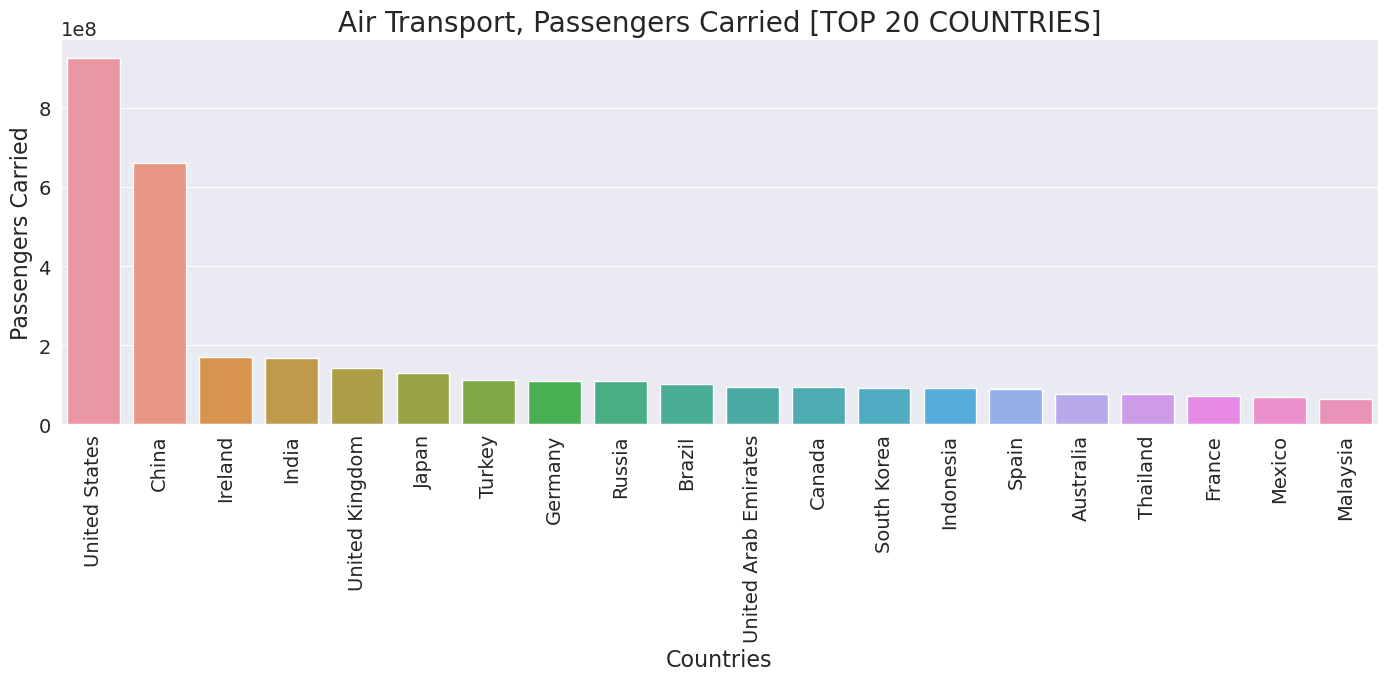

In [7]:
sns.barplot(x='Entity', y='Air transport, passengers carried', data=atpchd)

plt.xlabel('Countries', fontsize=16)
plt.ylabel('Passengers Carried', fontsize=16)
plt.xticks(rotation=90)
plt.title('Air Transport, Passengers Carried [TOP 20 COUNTRIES]', fontsize=20)

plt.show();

In [8]:
atpchd

,Entity,Year,"Air transport, passengers carried"
0,United States,2019,926737024.0
1,China,2019,659629056.0
2,Ireland,2019,170161856.0
3,India,2019,167499120.0
4,United Kingdom,2019,142392528.0
5,Japan,2019,130233352.0
6,Turkey,2019,111131472.0
7,Germany,2019,109633752.0
8,Russia,2019,108857904.0
9,Brazil,2019,102917544.0


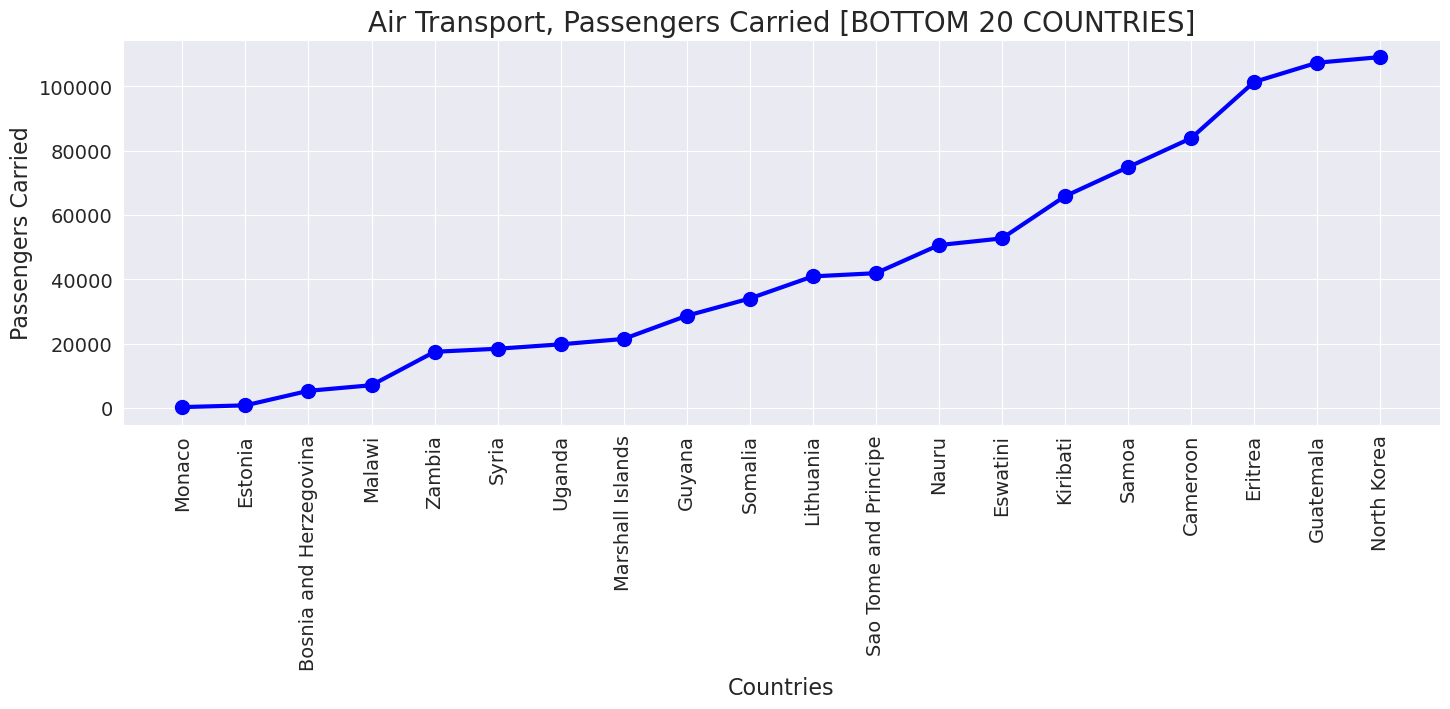

In [9]:
plt.plot(atpctl['Entity'], atpctl['Air transport, passengers carried'], 'o-b', lw=3, ms=10)

plt.xlabel('Countries', fontsize=16)
plt.ylabel('Passengers Carried', fontsize=16)
plt.xticks(rotation=90)
plt.title('Air Transport, Passengers Carried [BOTTOM 20 COUNTRIES]', fontsize=20)

plt.show();

In [10]:
atpctl

,Entity,Year,"Air transport, passengers carried"
158,Monaco,2019,316.000000
157,Estonia,2019,857.000000
156,Bosnia and Herzegovina,2019,5375.000000
155,Malawi,2019,7117.000000
154,Zambia,2019,17505.689453
153,Syria,2019,18456.644531
152,Uganda,2019,19822.500000
151,Marshall Islands,2019,21500.000000
150,Guyana,2019,28697.000000
149,Somalia,2019,34065.558594


In [11]:
atpcrefig = px.pie(atpcre, values='Air transport, passengers carried', names='Entity', title='Air Transport, Passengers Carried [REGION]')

atpcrefig.show()

In [12]:
atpcre

,Entity,Year,"Air transport, passengers carried"
0,East Asia and Pacific,2019,1.415411e+09
1,Europe and Central Asia,2019,1.283396e+09
2,North America,2019,1.020089e+09
3,European Union,2019,8.037226e+08
4,Latin America and Caribbean,2019,3.050613e+08
5,Middle East and North Africa,2019,2.764265e+08
6,South Asia,2019,1.909865e+08
7,Sub-Saharan Africa,2019,6.623633e+07


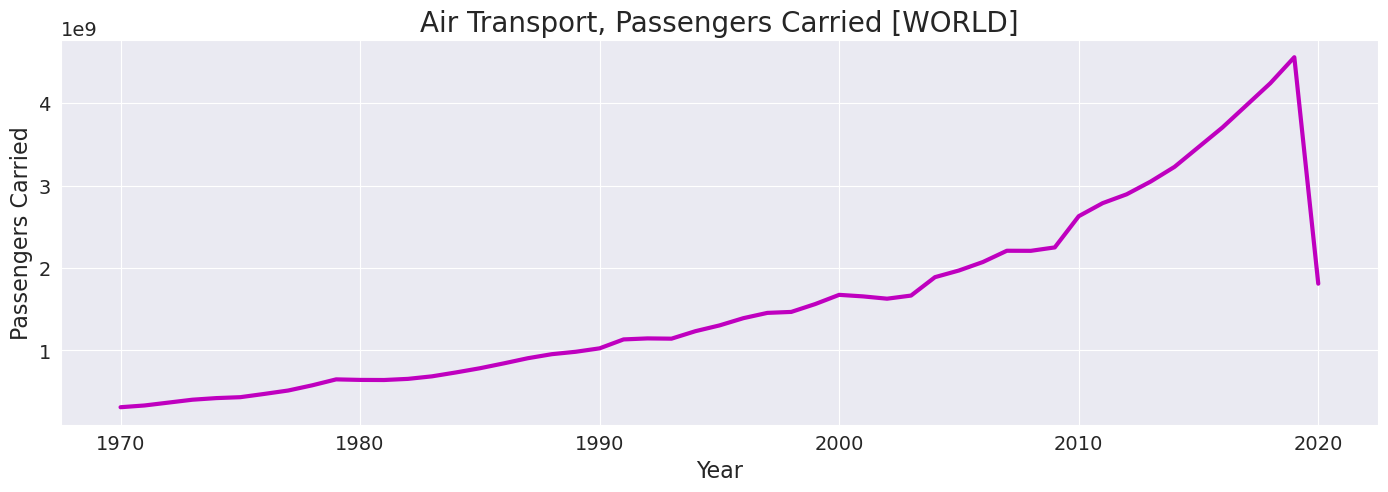

In [13]:
plt.plot(atpcwd['Year'], atpcwd['Air transport, passengers carried'], '-m', lw=3, ms=10)

plt.xlabel('Year', fontsize=16)
plt.ylabel('Passengers Carried', fontsize=16)
plt.title('Air Transport, Passengers Carried [WORLD]', fontsize=20)

plt.show();

In [14]:
atpcwd

,Entity,Year,"Air transport, passengers carried"
0,World,1970,3.104414e+08
1,World,1971,3.316049e+08
2,World,1973,4.015718e+08
3,World,1974,4.211452e+08
4,World,1975,4.322765e+08
5,World,1976,4.717734e+08
6,World,1977,5.132693e+08
7,World,1978,5.760900e+08
8,World,1979,6.484006e+08
9,World,1980,6.418729e+08


In [15]:
HTML('''<div class="flourish-embed flourish-bar-chart-race" data-src="visualisation/13199323"><script src="https://public.flourish.studio/resources/embed.js"></script></div>''')

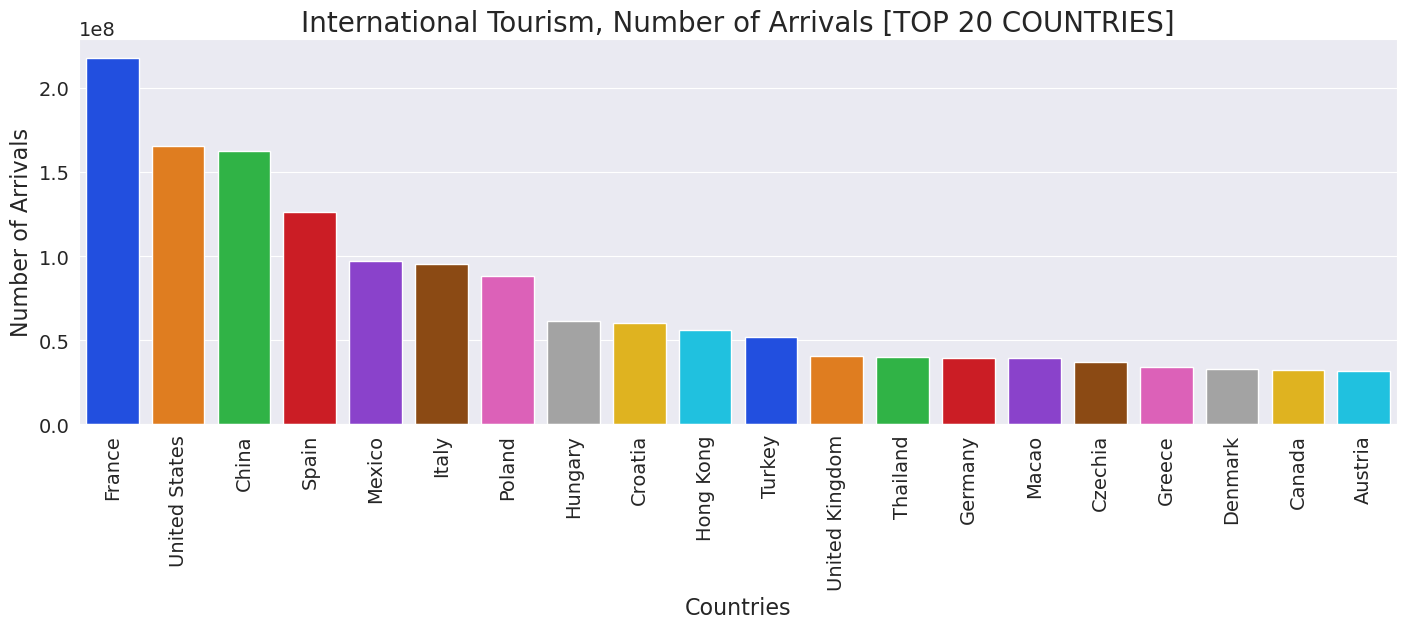

In [16]:
sns.barplot(x='Entity', y='International tourism, number of arrivals', data=itnoahd, palette='bright')

plt.xlabel('Countries', fontsize=16)
plt.ylabel('Number of Arrivals', fontsize=16)
plt.xticks(rotation=90)
plt.title('International Tourism, Number of Arrivals [TOP 20 COUNTRIES]', fontsize=20)

plt.show();

In [17]:
itnoahd

,Entity,Year,"International tourism, number of arrivals"
0,France,2019,217876992.0
1,United States,2019,165478000.0
2,China,2019,162538000.0
3,Spain,2019,126170000.0
4,Mexico,2019,97406000.0
5,Italy,2019,95399000.0
6,Poland,2019,88515000.0
7,Hungary,2019,61397000.0
8,Croatia,2019,60021000.0
9,Hong Kong,2019,55913000.0


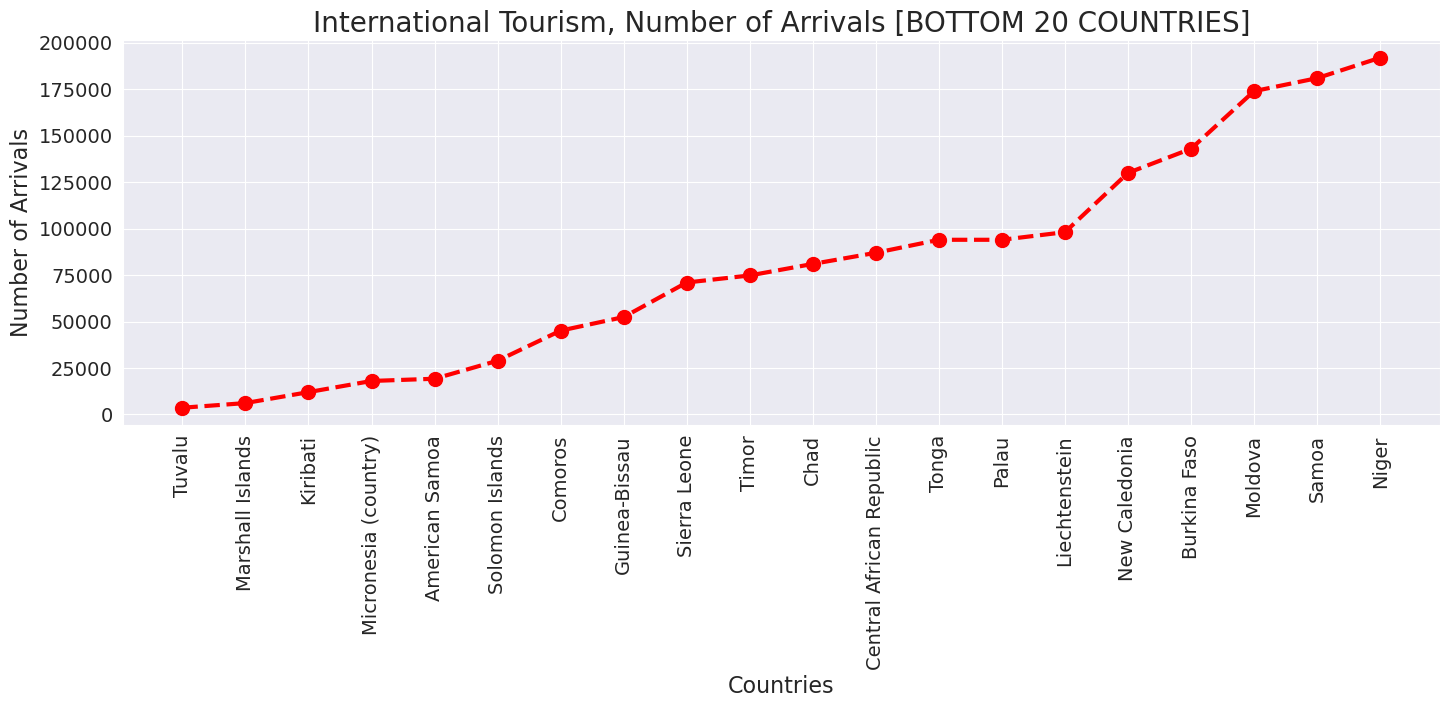

In [18]:
plt.plot(itnoatl['Entity'], itnoatl['International tourism, number of arrivals'], 'o--r', lw=3, ms=10)

plt.xlabel('Countries', fontsize=16)
plt.ylabel('Number of Arrivals', fontsize=16)
plt.xticks(rotation=90)
plt.title('International Tourism, Number of Arrivals [BOTTOM 20 COUNTRIES]', fontsize=20)

plt.show();

In [19]:
itnoatl

,Entity,Year,"International tourism, number of arrivals"
178,Tuvalu,2019,3600.0
177,Marshall Islands,2019,6100.0
176,Kiribati,2019,12000.0
175,Micronesia (country),2019,18000.0
174,American Samoa,2019,19200.0
173,Solomon Islands,2019,28900.0
172,Comoros,2019,45100.0
171,Guinea-Bissau,2019,52400.0
170,Sierra Leone,2019,71000.0
169,Timor,2019,74800.0


In [20]:
itnoarefig = px.pie(itnoare, values='International tourism, number of arrivals', names='Entity', title='International Tourism, Number of Arrivals [REGION]')

itnoarefig.show()

In [21]:
itnoare

,Entity,Year,"International tourism, number of arrivals"
0,East Asia and Pacific,2019,4.908040e+08
1,Europe and Central Asia,2019,1.199188e+09
2,European Union,2019,9.688733e+08
3,Latin America and Caribbean,2019,2.018560e+08
4,Middle East and North Africa,2019,1.525713e+08
5,North America,2019,1.987130e+08
6,South Asia,2019,2.710276e+07
7,Sub-Saharan Africa,2019,5.601450e+07


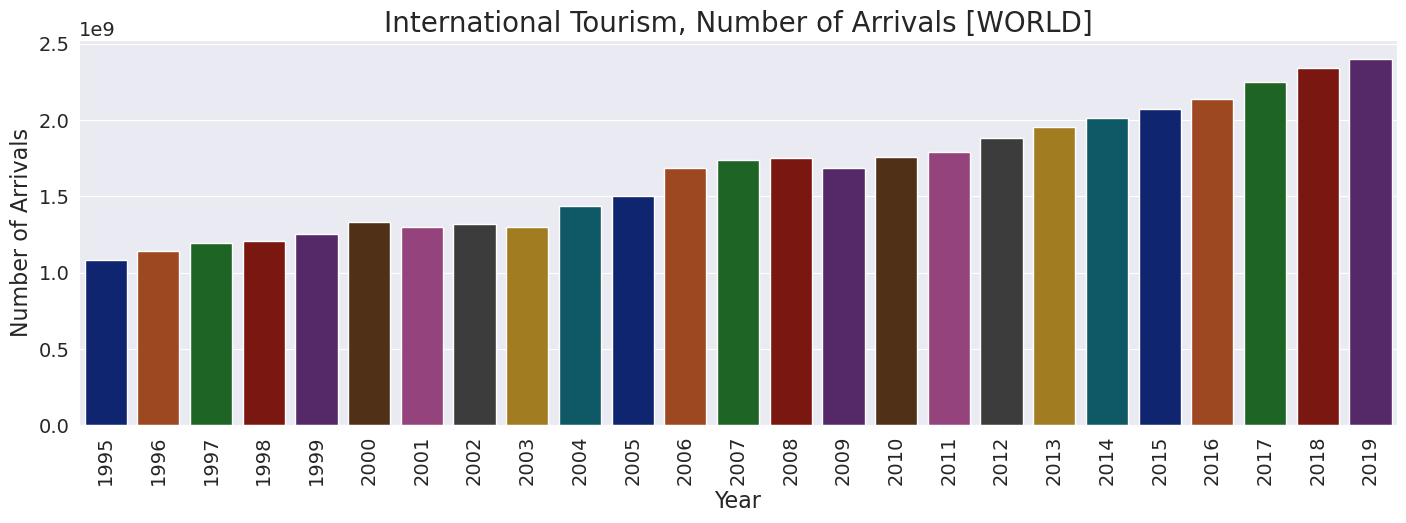

In [22]:
sns.barplot(x='Year', y='International tourism, number of arrivals', data=itnoawd, palette='dark')

plt.xlabel('Year', fontsize=16)
plt.ylabel('Number of Arrivals', fontsize=16)
plt.xticks(rotation=90)
plt.title('International Tourism, Number of Arrivals [WORLD]', fontsize=20)

plt.show();

In [23]:
itnoawd

,Entity,Year,"International tourism, number of arrivals"
0,World,1995,1.082522e+09
1,World,1996,1.143489e+09
2,World,1997,1.193996e+09
3,World,1998,1.209957e+09
4,World,1999,1.254467e+09
5,World,2000,1.332379e+09
6,World,2001,1.299005e+09
7,World,2002,1.319582e+09
8,World,2003,1.300067e+09
9,World,2004,1.436450e+09


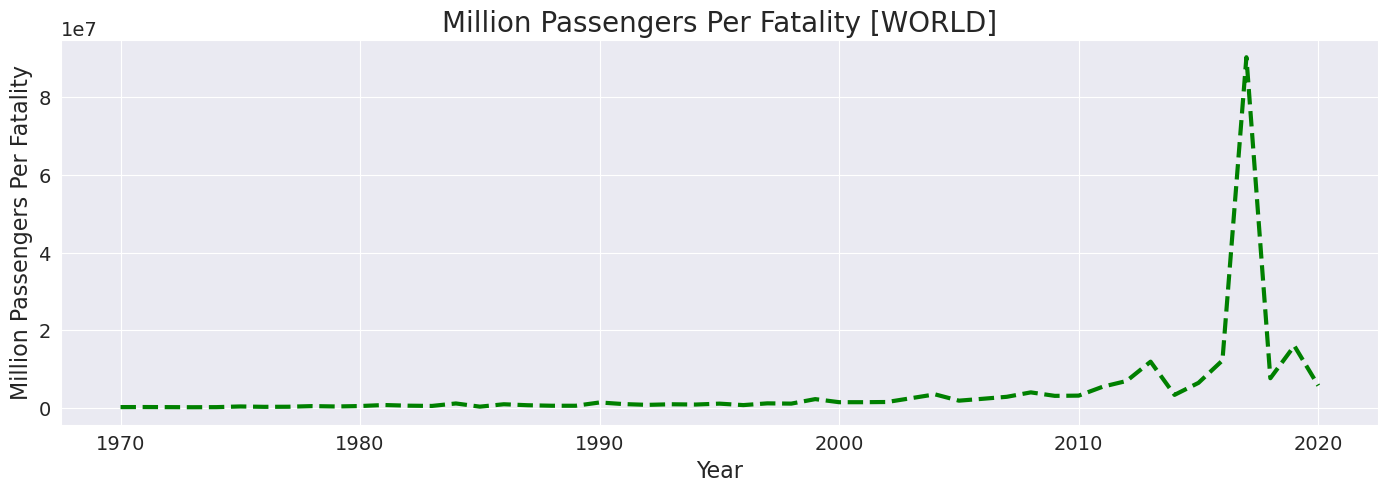

In [24]:
plt.plot(mppfwd['Year'], mppfwd['Million passengers per fatality'], '--g', lw=3, ms=10)

plt.xlabel('Year', fontsize=16)
plt.ylabel('Million Passengers Per Fatality', fontsize=16)
plt.title('Million Passengers Per Fatality [WORLD]', fontsize=20)

plt.show();

In [25]:
mppfwd

,Entity,Year,Million passengers per fatality
0,World,1970,209757.70
1,World,1971,225735.11
2,World,1973,176903.87
3,World,1974,199594.89
4,World,1975,374265.37
5,World,1976,274606.17
6,World,1977,299806.83
7,World,1978,466469.62
8,World,1979,370726.47
9,World,1980,482248.63


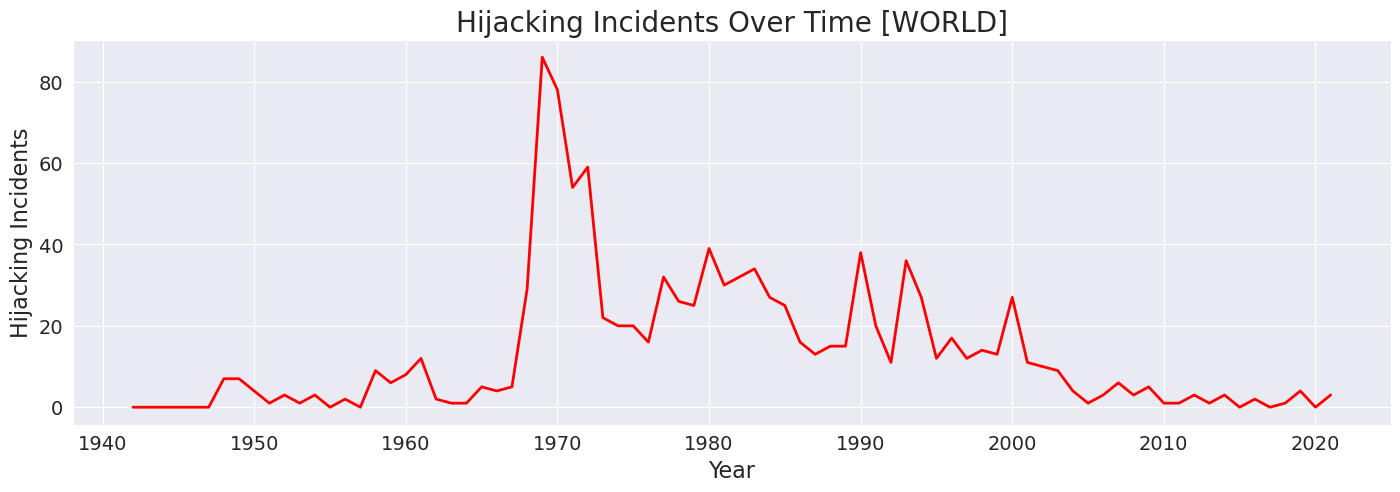

In [26]:
plt.plot(hifacawd['Year'], hifacawd['Hijacking incidents'], '-r', lw=2, ms=10)

plt.xlabel('Year', fontsize=16)
plt.ylabel('Hijacking Incidents', fontsize=16)
plt.title('Hijacking Incidents Over Time [WORLD]', fontsize=20)

plt.show();

In [27]:
hifacawd

,Entity,Year,Hijacking incidents,Fatal accidents from commercial airliners
0,World,1942,0,NaN
1,World,1943,0,NaN
2,World,1944,0,NaN
3,World,1945,0,NaN
4,World,1946,0,60.0
5,World,1947,0,73.0
6,World,1948,7,80.0
7,World,1949,7,72.0
8,World,1950,4,56.0
9,World,1951,1,60.0


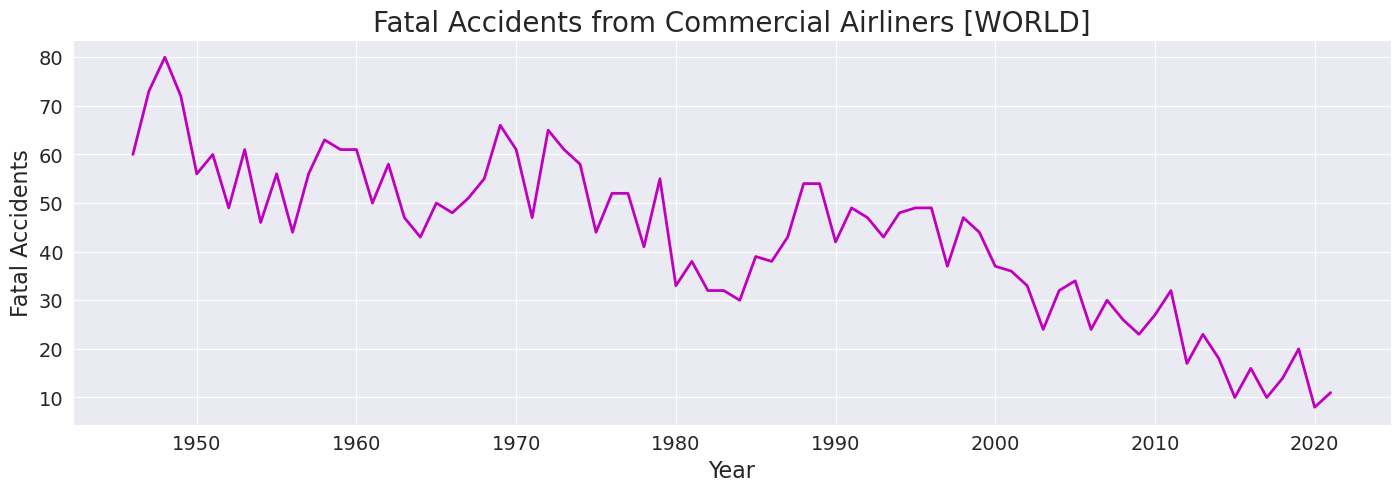

In [28]:
plt.plot(hifacawd['Year'], hifacawd['Fatal accidents from commercial airliners'], '-m', lw=2, ms=10)

plt.xlabel('Year', fontsize=16)
plt.ylabel('Fatal Accidents', fontsize=16)
plt.title('Fatal Accidents from Commercial Airliners [WORLD]', fontsize=20)

plt.show();

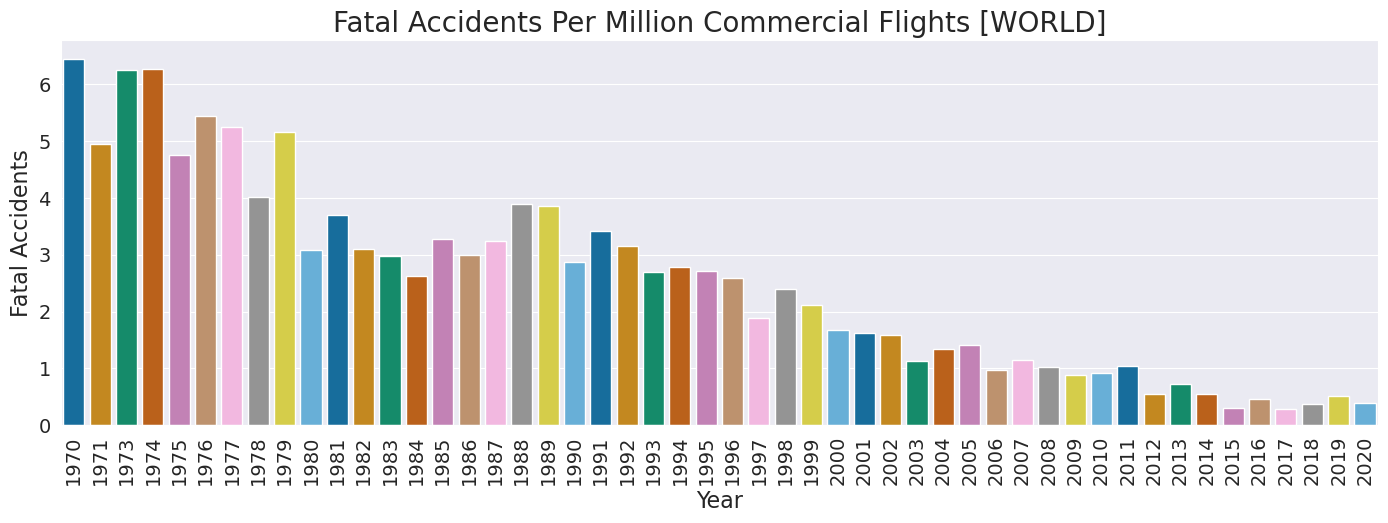

In [29]:
sns.barplot(x='Year', y='Fatal accidents per million commercial flights', data=fapmcfwd, palette='colorblind')

plt.xlabel('Year', fontsize=16)
plt.ylabel('Fatal Accidents', fontsize=16)
plt.xticks(rotation=90)
plt.title('Fatal Accidents Per Million Commercial Flights [WORLD]', fontsize=20)

plt.show();

In [30]:
fapmcfwd

,Entity,Year,Fatal accidents per million commercial flights
0,World,1970,6.456188
1,World,1971,4.945026
2,World,1973,6.246864
3,World,1974,6.266951
4,World,1975,4.759484
5,World,1976,5.437681
6,World,1977,5.244103
7,World,1978,4.026041
8,World,1979,5.162671
9,World,1980,3.082701


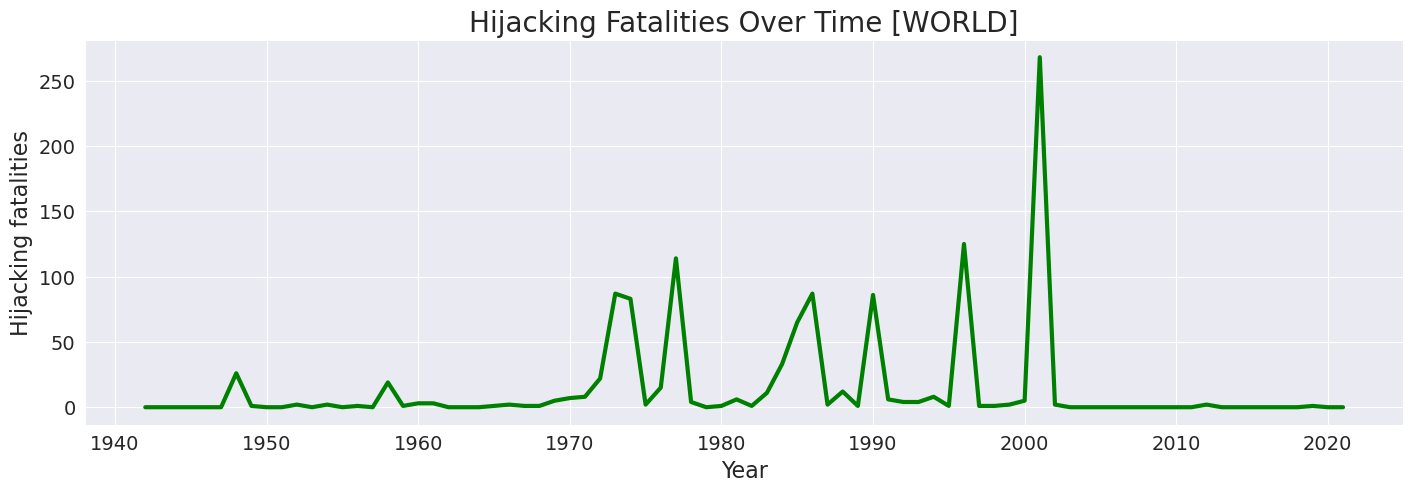

In [31]:
plt.plot(hfffcawd['Year'], hfffcawd['Hijacking fatalities'], '-g', lw=3, ms=10)

plt.xlabel('Year', fontsize=16)
plt.ylabel('Hijacking fatalities', fontsize=16)
plt.title('Hijacking Fatalities Over Time [WORLD]', fontsize=20)

plt.show();

In [32]:
hfffcawd

,Entity,Year,Hijacking fatalities,Fatalities from commercial airliners
0,World,1942,0,NaN
1,World,1943,0,NaN
2,World,1944,0,NaN
3,World,1945,0,NaN
4,World,1946,0,770.0
5,World,1947,0,1043.0
6,World,1948,26,1238.0
7,World,1949,1,1110.0
8,World,1950,0,1064.0
9,World,1951,0,918.0


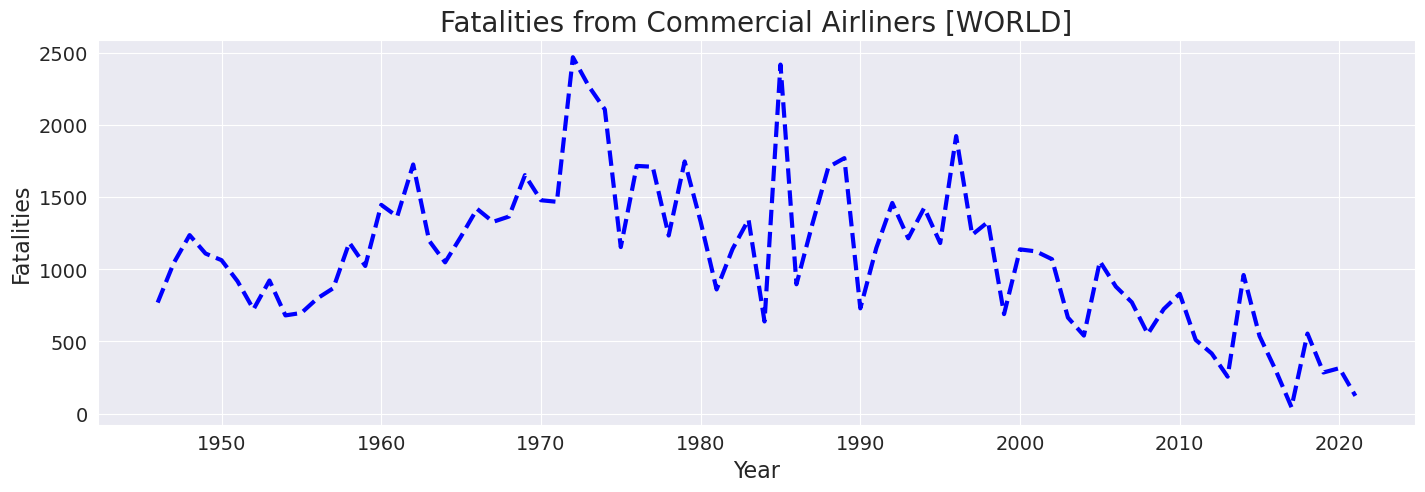

In [33]:
plt.plot(hfffcawd['Year'], hfffcawd['Fatalities from commercial airliners'], '--b', lw=3, ms=10)

plt.xlabel('Year', fontsize=16)
plt.ylabel('Fatalities', fontsize=16)
plt.title('Fatalities from Commercial Airliners [WORLD]', fontsize=20)

plt.show();

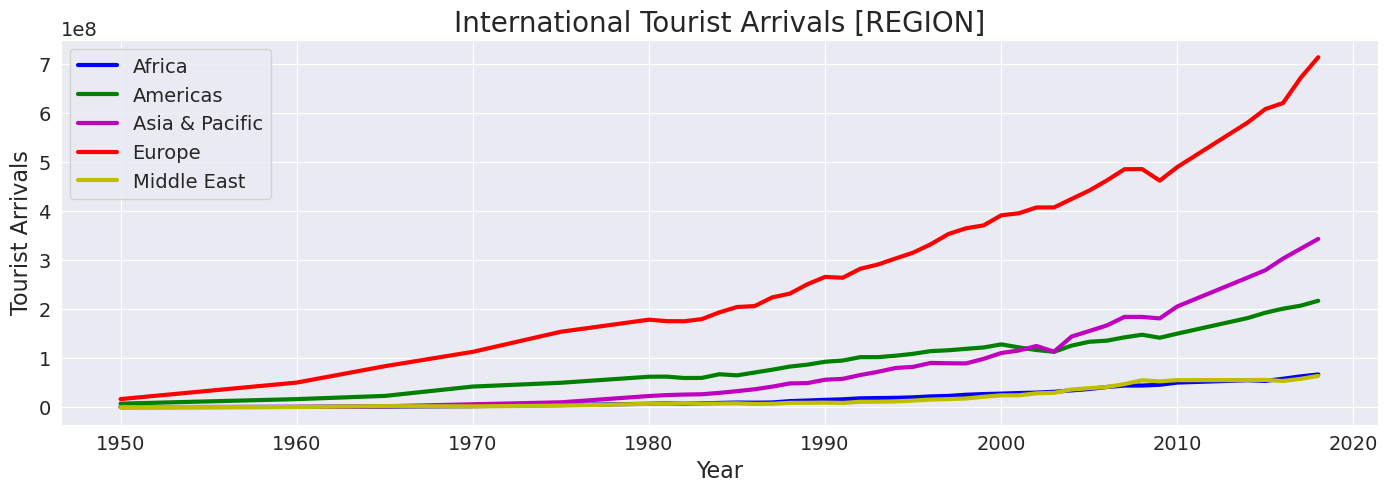

In [34]:
itareaf = itare[itare.Entity == 'Africa']
itaream = itare[itare.Entity == 'Americas']
itareap = itare[itare.Entity == 'Asia & Pacific']
itareeu = itare[itare.Entity == 'Europe']
itareme = itare[itare.Entity == 'Middle East']

plt.plot(itareaf['Year'], itareaf['International Tourist Arrivals'], '-b', lw=3, ms=10)
plt.plot(itaream['Year'], itaream['International Tourist Arrivals'], '-g', lw=3, ms=10)
plt.plot(itareap['Year'], itareap['International Tourist Arrivals'], '-m', lw=3, ms=10)
plt.plot(itareeu['Year'], itareeu['International Tourist Arrivals'], '-r', lw=3, ms=10)
plt.plot(itareme['Year'], itareme['International Tourist Arrivals'], '-y', lw=3, ms=10)

plt.xlabel('Year', fontsize=16)
plt.ylabel('Tourist Arrivals', fontsize=16)
plt.title('International Tourist Arrivals [REGION]', fontsize=20)
plt.legend(['Africa','Americas','Asia & Pacific','Europe','Middle East'])

plt.show();

In [35]:
itare

,Entity,Year,International Tourist Arrivals
0,Africa,1950,500000
1,Africa,1960,800000
2,Africa,1965,1400000
3,Africa,1970,2400000
4,Africa,1975,4700000
5,Africa,1980,7200000
6,Africa,1981,8100000
7,Africa,1982,7600000
8,Africa,1983,8200000
9,Africa,1984,8900000


# Concluding Remarks

In conclusion, tourism and air transport are closely linked and play a significant role in the global economy. The growth of international tourism has been facilitated by air transport, but the safety of air travel is a crucial concern that cannot be ignored. The metrics of international tourist arrivals, million passengers per fatality, fatalities per million passengers, hijacking incidents, fatal accidents, and fatalities provide insights into the safety of air transport. The aviation industry has made significant strides in improving safety standards, but it must continue to prioritize safety while providing fast and efficient travel options for tourists. Only through sustained efforts to ensure the safety and security of air travel can the tourism industry continue to thrive and contribute to the global economy.